# Объединим датасеты

Мы получили датасет путем скрапинга и по апи. Теперь соединим их таким образом, чтобы объявление находилось сразу в обоих датасетах


In [2174]:
import pandas as pd
import numpy as np

In [2175]:
api_1_df = pd.read_csv('final_data.csv')
skrapping_df = pd.read_csv('url_final.csv')

In [2176]:
api_1_df.head(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,front_crash_rating,side_crash_rating,rollover_rating,manufacturer_country,model_exists,marketcheck_avg_price,marketcheck_avg_days_on_market,marketcheck_popularity_score,matched_model_name,model_match_status
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,toyota,crown,1990,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,False,NaN,NaN,0.0,NaN,not_found
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,224,15,2,6,20,...,4,4,4,MEXICO,True,13370.82,294.74,1535.0,elantra,matched
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,toyota,camry,2019,6,361,18,0,1,21,...,5,5,5,UNITED STATES (USA),True,18882.84,238.00,1849.0,camry,matched


In [2177]:
api_1_df.shape

(10013, 21)

In [2178]:
skrapping_df.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,"Продажа Toyota Crown, 1990 год в Екатеринбурге",1990.0,ekaterinburg,toyota,crown,500000.0,"бензин, 2.0 л",АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,"Продажа Hyundai Elantra, 2020 год в Перми",2020.0,perm,hyundai,elantra,689000.0,"бензин, 2.0 л",АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,"Продажа Toyota Camry, 2019 год во Всеволожске",2019.0,vsevolozhsk,toyota,camry,1600000.0,"бензин, 2.0 л",АКПП,400000.0,передний,седан,белый,левый,150.0,: Машина ходовое вложение не требует Город : В...


In [2179]:
skrapping_df.shape

(10506, 16)

In [2180]:
df = pd.merge(api_1_df, skrapping_df, on = ['url', 'make', 'model', 'year'], how = 'inner')

In [2181]:
df.shape

(10013, 33)

In [2182]:
df.sample(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
3953,https://auto.drom.ru/krasnoyarsk/chery/tiggo/8...,chery,tiggo,2015,0,0,0,0,0,0,...,969000.0,"бензин, 1.8 л",робот,114300.0,передний,NaN,белый,левый,132.0,: Федеральная сеть автосалонов Crystal Motors ...
8415,https://auto.drom.ru/krasnoyarsk/zeekr/001/719...,zeekr,001,2023,0,0,0,0,0,0,...,5990000.0,электро,АКПП,340.0,4WD,NaN,черный,левый,544.0,: АБСОЛЮТНО НОВЫЙ ZEEKR 001 В НАЛИЧИИ! 2023 ГО...
3328,https://auto.drom.ru/novosibirsk/mitsubishi/la...,mitsubishi,lancer,2011,3,49,1,0,0,1,...,750000.0,"бензин, 1.5 л",АКПП,165000.0,передний,седан,красный,левый,109.0,": Машина во владении уже 5 лет, нареканий в пл..."


In [2183]:
df.duplicated().sum()

np.int64(0)

на всякий проверяем на дубликаты, но их и не будет, так как мы при сборе датасета их удаляли

In [2184]:
df.dtypes

,0
url,object
make,object
model,object
year,int64
recalls_count,int64
complaints_count,int64
injuries,int64
deaths,int64
has_fire,int64
has_crash,int64


Давайте приведем все к корректным типам данных. В целом, почти все типы данных корректны, только в столбцах, связанных с рейтингом должен быть float, а не object. Такое возникает потому что пропуск прописывается фразой 'Not Rated'. Давайте все такие значения заменим на Nan

In [2185]:
print('Количество Not Rated в overall_rating', (df['overall_rating'] == 'Not Rated').sum())
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Not Rated в front_crash_rating', (df['front_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Not Rated в side_crash_rating', (df['side_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Not Rated в rollover_rating', (df['rollover_rating'] == 'Not Rated').sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Not Rated в overall_rating 2421
Количество Nan в overall_rating 6320
Количество Not Rated в front_crash_rating 2355
Количество Nan в front_crash_rating 6320
Количество Not Rated в side_crash_rating 2321
Количество Nan в side_crash_rating 6320
Количество Not Rated в rollover_rating 1644
Количество Nan в rollover_rating 6320


In [2186]:
df.loc[df['overall_rating'] == 'Not Rated', 'overall_rating'] = np.nan
df.loc[df['front_crash_rating'] == 'Not Rated', 'front_crash_rating'] = np.nan
df.loc[df['side_crash_rating'] == 'Not Rated', 'side_crash_rating'] = np.nan
df.loc[df['rollover_rating'] == 'Not Rated', 'rollover_rating'] = np.nan

In [2187]:
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Nan в overall_rating 8741
Количество Nan в front_crash_rating 8675
Количество Nan в side_crash_rating 8641
Количество Nan в rollover_rating 7964


In [2188]:
df['overall_rating'] = pd.to_numeric(df['overall_rating'])
df['front_crash_rating'] = pd.to_numeric(df['front_crash_rating'])
df['side_crash_rating'] = pd.to_numeric(df['side_crash_rating'])
df['rollover_rating'] = pd.to_numeric(df['rollover_rating'])

Поменяли на Nan, видим, что очень большое количество пропусков в этих столбцах, давайте в целом глянем на все пропуски

# Обработка пропусков

In [2189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10013 entries, 0 to 10012
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             10013 non-null  object 
 1   make                            10013 non-null  object 
 2   model                           10013 non-null  object 
 3   year                            10013 non-null  int64  
 4   recalls_count                   10013 non-null  int64  
 5   complaints_count                10013 non-null  int64  
 6   injuries                        10013 non-null  int64  
 7   deaths                          10013 non-null  int64  
 8   has_fire                        10013 non-null  int64  
 9   has_crash                       10013 non-null  int64  
 10  overall_rating                  1272 non-null   float64
 11  front_crash_rating              1338 non-null   float64
 12  side_crash_rating               

Вот теперь все супер! Все столбцы имеют корректные типы данных. Теперь будем смотреть на пропуски

# Давайте посмотрим на корреляцию столбцов, принимающих числовые значения


In [2190]:
df_numeric = df[['year', 'recalls_count', 'complaints_count', 'injuries', 'deaths', 'has_fire', 'has_crash', 'overall_rating',
                'front_crash_rating', 'side_crash_rating', 'rollover_rating', 'price', 'mileage', 'hp']]
df_numeric.head(5)

,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,overall_rating,front_crash_rating,side_crash_rating,rollover_rating,price,mileage,hp
0,1990,0,0,0,0,0,0,NaN,NaN,NaN,NaN,500000.0,280000.0,170.0
1,2020,3,224,15,2,6,20,4.0,4.0,4.0,4.0,689000.0,88000.0,150.0
2,2019,6,361,18,0,1,21,5.0,5.0,5.0,5.0,1600000.0,400000.0,150.0
3,2007,3,88,19,0,1,11,NaN,NaN,NaN,NaN,450000.0,238000.0,102.0
4,2004,0,33,15,0,2,11,NaN,NaN,NaN,NaN,495000.0,NaN,102.0


In [2191]:
import plotly.express as px

corr_matrix = df_numeric.corr(method = 'spearman')
fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu', title = 'Корреляция признаков между собой')
fig.show()



Видим, что корреляция year и mileage -0.67 - это обозначает обратную зависимость, то есть когда увеличивается одна переменная, другая уменьшается. То есть уменьшение года сопровождается увеличением пробега

year и price имеют положиетльную зависимость, когда увеличивается одна переменная, увеличивается и вторая. Получается, что чем новее машина, тем больше ее цена


Видим еще квадратик голубой в левом верхнем углу. Как раз все эти признаки имеют положительную зависимость. Они все относятся к критериям безопасности и качества авто

Более того видим положительную зависимость между жалобами и пострадавшими

#  Univariant Analysis

Теперь давайте посмотрим как у нас выглядит каждый признак


**url** - ссылка на объявление, в нашем случае уникальный идентификатор автомобиля. Именно по ссылке производился весь сбор данных в скрапинге


**1.make** - производитель (марка) автомобиля

**2.model** - модель автомобиля

**3.year** - год выпуска конкретного автомобиля

**4.recalls_count** - количество отзывных компаний на конкретную модель автомобиля

**5.complaints_count** - количество жалоб на конкретную модель

**6.injuries** - количесвтво травмы, полученные при использовании данной модели авто

**7.deaths** - колчество умерших, при использовании данной модели авто

**8.has_fire** -колчество возгораний данной модели авто

**9.has_crash** - количество аварий данной модели авто

**10.overall_rating** - общий рейтинг безопасности авто

**11.front_crash_rating** - рейтинг безопасности авто при столкновении прямо

**12.side_crash_rating** - рейтинг безопасности авто при столкновении боком

**13.rollover_rating** - рейтинг безопасности авто при перевороте

**14.manufacturer_country** - страна выпуска модели автомобиля

**15.model_exists** - маркер о существовании такой модели автомобиля. В нашем датасете все автомобили имеют значение True

**16.title** - заголовок объявления о продаже конкретного авто

**17.city** - город, в котором осуществляется продажа конкретного авто

**18.price** - цена конкретного автомобиля

**19.engine** - тип топлива, объем двигателя и дополнительное оборудование

**20.transmission** - тип коробки передач у конкретного автомобиля

**21.mileage** - пробег конкретного автомобиля

**22.drive** - тип привода конкретного автомобиля

**23.body** - тип кузова конкретного автомобиля

**24.color** - цвет конкретного автомобиля

**25.wheel** - расположение руля в конкретном автомобиле

**26.hp** - количество лошадиных сил конкретного автомобиля

**27.description** - описание автомобиля, взятое из объявления

часто содержит очень полезную дополнительную информацию, источник продажи (собственник или автосалон) и остальные нюансы(количество собственников, дтп)



Давайте теперь посмотрим на каждый признак по отдельности


**1.make** - производитель (марка) автомобиля

давайте в целом посмотрим, сколько объявлений о продаже приходится на конкретные марки авто

In [2192]:
make_pivot = pd.pivot_table(df, values = 'url', index = 'make', aggfunc = 'count').sort_values(by = 'url')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'dodge'),
  Text(1, 0, 'zeekr'),
  Text(2, 0, 'geely'),
  Text(3, 0, 'chevrolet'),
  Text(4, 0, 'lexus'),
  Text(5, 0, 'tesla'),
  Text(6, 0, 'mini'),
  Text(7, 0, 'porsche'),
  Text(8, 0, 'subaru'),
  Text(9, 0, 'suzuki'),
  Text(10, 0, 'jeep'),
  Text(11, 0, 'jaguar'),
  Text(12, 0, 'cadillac'),
  Text(13, 0, 'infiniti'),
  Text(14, 0, 'volvo'),
  Text(15, 0, 'opel'),
  Text(16, 0, 'fiat'),
  Text(17, 0, 'citroen'),
  Text(18, 0, 'chery'),
  Text(19, 0, 'skoda'),
  Text(20, 0, 'mercedes-benz'),
  Text(21, 0, 'haval'),
  Text(22, 0, 'audi'),
  Text(23, 0, 'bmw'),
  Text(24, 0, 'peugeot'),
  Text(25, 0, 'lada'),
  Text(26, 0, 'hyundai'),
  Text(27, 0, 'nissan'),
  Text(28, 0, 'toyota'),
  Text(29, 0, 'volkswagen'),
  Text(30, 0, 'renault'),
  Text(31, 0, 'honda'),
  Tex

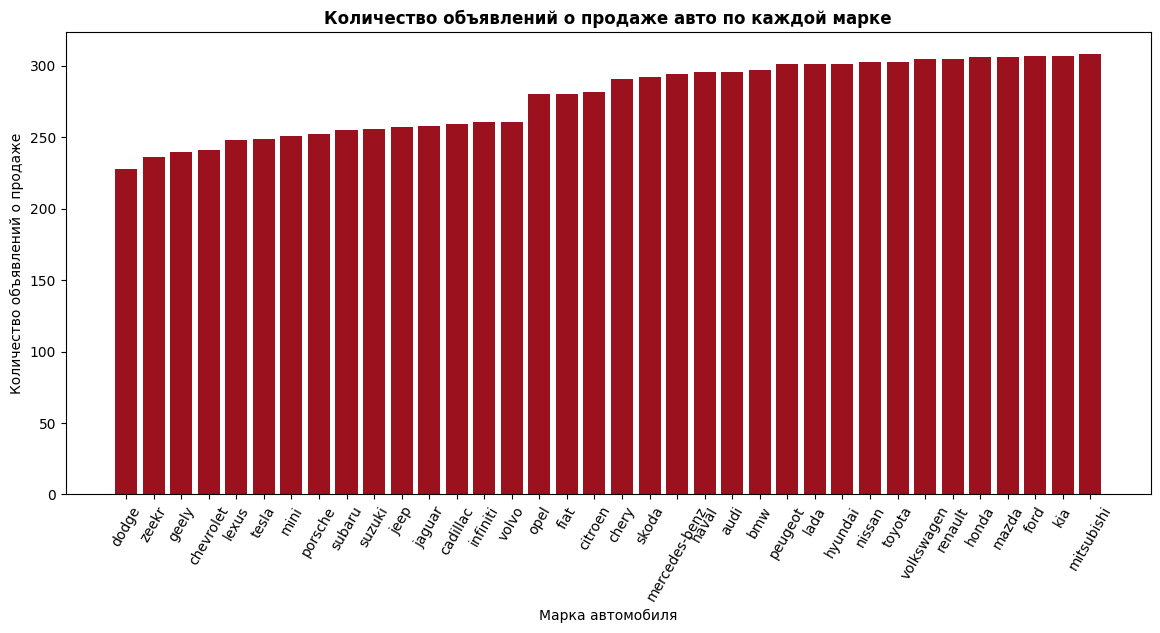

In [2193]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(make_pivot.index, make_pivot['url'], color = '#9B111E')


plt.title('Количество объявлений о продаже авто по каждой марке', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество объявлений о продаже')
plt.xticks(rotation = 60)

КАКОЙ-ТО ТЕКСТИК

2.model - модель автомобиля

здесь будем рассматривать количество различных моделей авто у одного производителя (марки)

In [2194]:
model_pivot = pd.pivot_table(df, values = 'model', index = 'make', aggfunc = 'nunique').sort_values(by = 'model')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'tesla'),
  Text(1, 0, 'zeekr'),
  Text(2, 0, 'mini'),
  Text(3, 0, 'porsche'),
  Text(4, 0, 'skoda'),
  Text(5, 0, 'jeep'),
  Text(6, 0, 'haval'),
  Text(7, 0, 'jaguar'),
  Text(8, 0, 'cadillac'),
  Text(9, 0, 'subaru'),
  Text(10, 0, 'opel'),
  Text(11, 0, 'bmw'),
  Text(12, 0, 'dodge'),
  Text(13, 0, 'geely'),
  Text(14, 0, 'renault'),
  Text(15, 0, 'ford'),
  Text(16, 0, 'chevrolet'),
  Text(17, 0, 'audi'),
  Text(18, 0, 'volvo'),
  Text(19, 0, 'kia'),
  Text(20, 0, 'peugeot'),
  Text(21, 0, 'chery'),
  Text(22, 0, 'fiat'),
  Text(23, 0, 'suzuki'),
  Text(24, 0, 'volkswagen'),
  Text(25, 0, 'mercedes-benz'),
  Text(26, 0, 'hyundai'),
  Text(27, 0, 'citroen'),
  Text(28, 0, 'infiniti'),
  Text(29, 0, 'lada'),
  Text(30, 0, 'mazda'),
  Text(31, 0, 'mitsubishi'),
  Tex

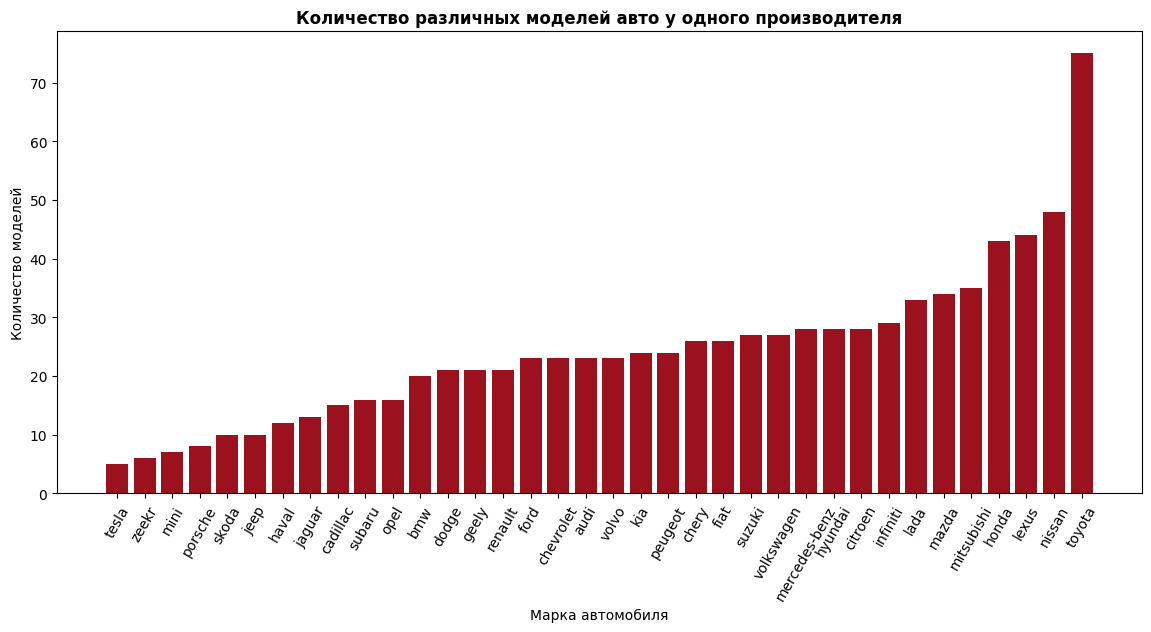

In [2195]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(model_pivot.index, model_pivot['model'], color = '#9B111E')


plt.title('Количество различных моделей авто у одного производителя', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество моделей')
plt.xticks(rotation = 60)

ТУТ КАКОЙ-ТО ТЕКСТ

3.year - год выпуска конкретного автомобиля

давайте посмотрим как автомобили из нашего датасета распределены по годам производства

In [2196]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей')

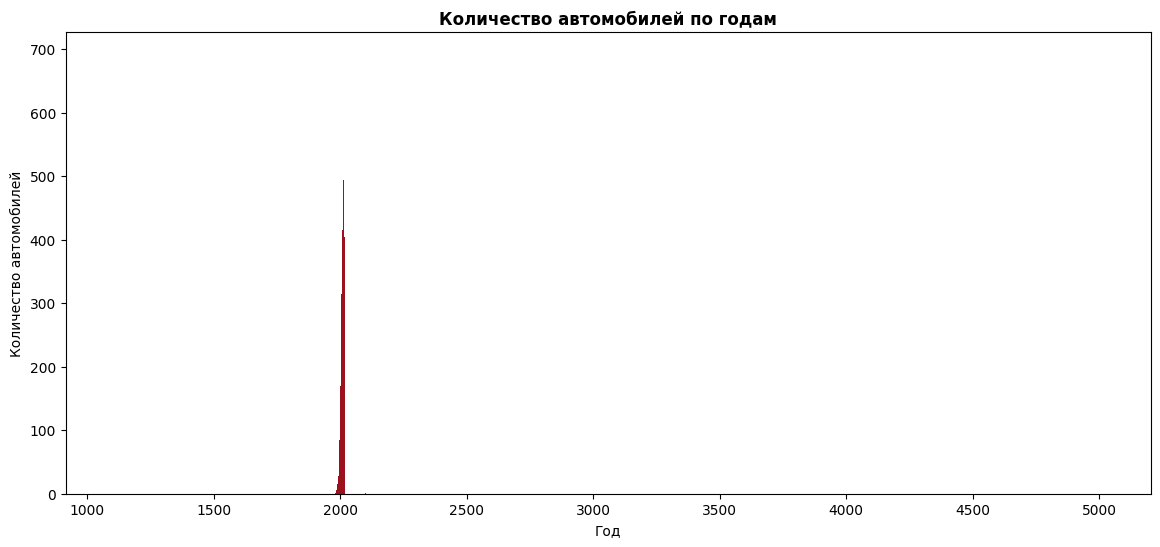

In [2197]:
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')


In [2198]:
df = df[df['year'] <= 2026]
df = df[df['year'] >= 1980]


In [2199]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей')

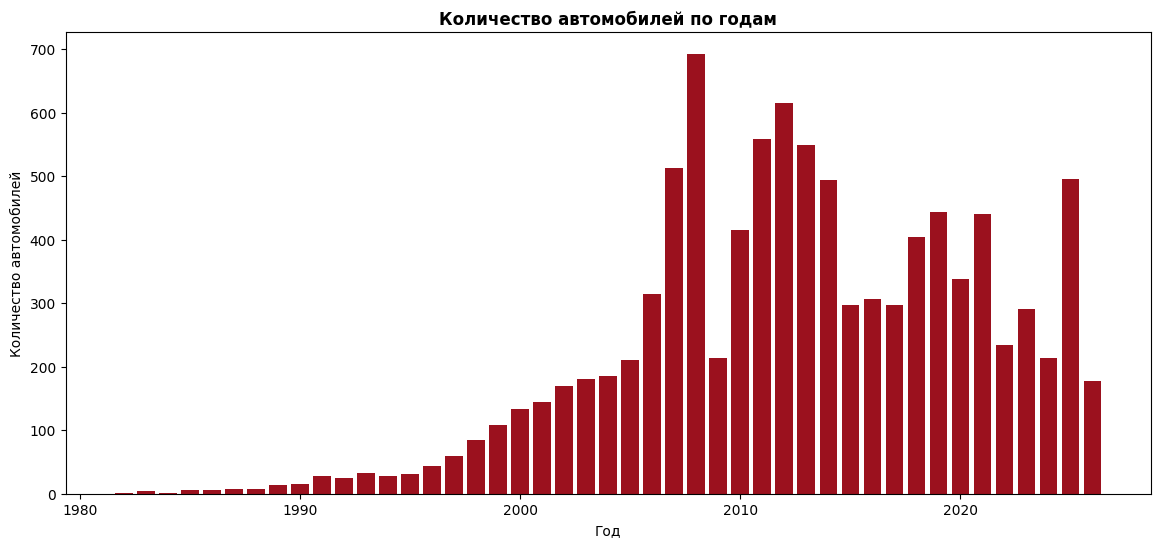

In [2200]:
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')

КАКОЙ-ТО ТЕКСТИК ПРО ЭТО ВСЕ

4.recalls_count - количество отзывных компаний на конкретную модель автомобиля

In [2201]:
recalls_table = df['recalls_count'].value_counts().sort_index()
recalls_table

,count
recalls_count,
0,6078
1,471
2,586
3,533
4,456
5,341
6,317
7,225
8,92


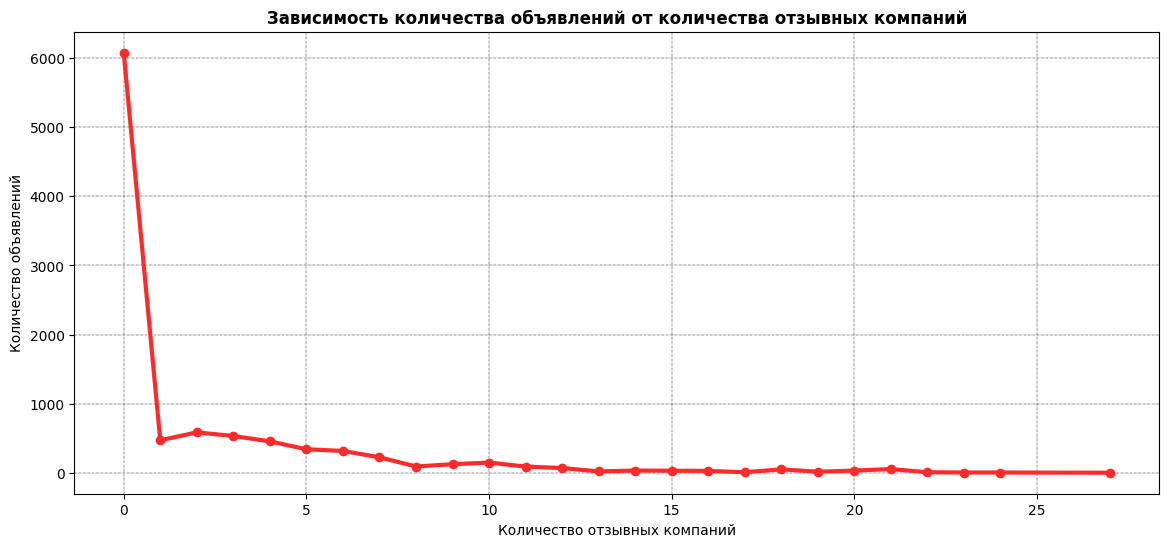

In [2202]:
plt.figure(figsize = (14, 6))
plt.plot(recalls_table.index, recalls_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.title('Зависимость количества объявлений от количества отзывных компаний', fontweight = 'bold')
plt.xlabel('Количество отзывных компаний')
plt.ylabel('Количество объявлений')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)

КАКОЙ-ТО ТЕКСТ НАДО НАПИСАТЬ

5.complaints_count - количество жалоб на конкретную модель

In [2203]:
complaints_table = pd.cut(df['complaints_count'], bins = [0, 50, 100, 150, 200, 500, 1000, 2000, 3000, 4000, 6000],
    labels = ['до 50', '50 – 100', '100 – 150', '150 – 200', '200 – 500', '500 – 1000', '1000 - 2000', '2000 - 3000', '3000 - 4000', '4000+'])
complaints_table = complaints_table.value_counts().sort_index()

Text(0, 0.5, 'Количество автомобилей')

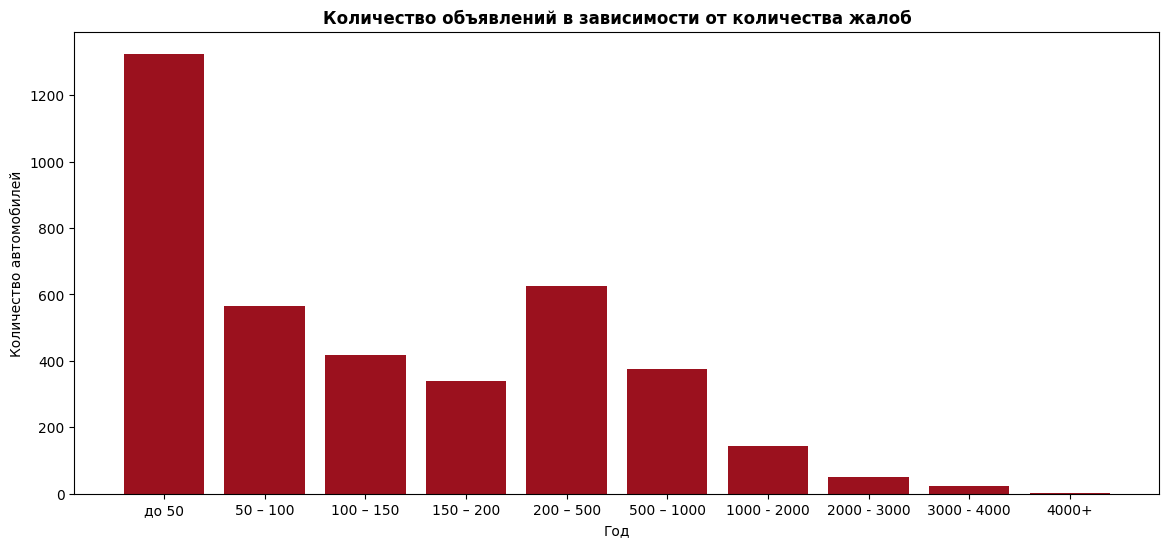

In [2204]:
plt.figure(figsize = (14, 6))
plt.bar(complaints_table.index, complaints_table, color = '#9B111E')


plt.title('Количество объявлений в зависимости от количества жалоб', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')

КАКОЙ-ТО ОЧЕРЕНДОЙ ТЕКСТ

6.injuries - количесвтво травмы, полученные при использовании данной модели авто

7.deaths - колчество умерших, при использовании данной модели авто

Рассмотрим как выглядит распределение этих признаков

In [2205]:
injuries_table = df['injuries'].value_counts().sort_index()
deaths_table = df['deaths'].value_counts().sort_index()
deaths_table = np.log1p(deaths_table)
injuries_table = np.log1p(injuries_table)

Text(0.5, 0, 'Количество погибших')

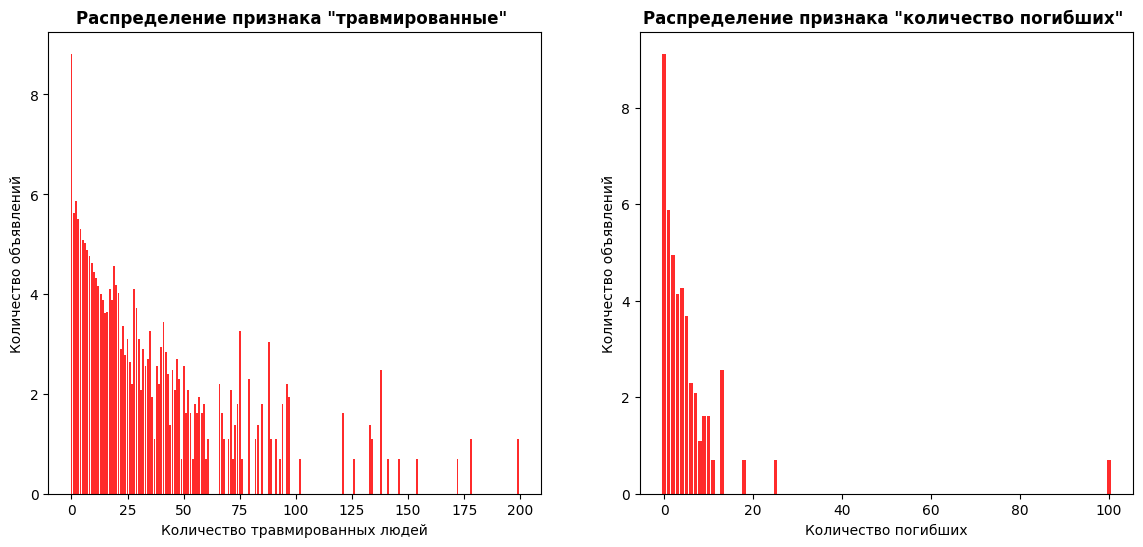

In [2206]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(injuries_table.index, injuries_table, color = '#FF2B2B')
plt.title('Распределение признака "травмированные" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество травмированных людей')

plt.subplot(1, 2, 2)
plt.bar(deaths_table.index, deaths_table, color = '#FF2B2B')
plt.title('Распределение признака "количество погибших" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество погибших')



КАКОЙ-ТО ВЫВОД: УМИРАЮТ В РАЗЫ МЕНЬШЕ ЧЕМ ТРАВМИРУЮТСЯ

Теперь рассмотрим наши рейтинговые признаки
**10.overall_rating** - общий рейтинг безопасности авто

**11.front_crash_rating** - рейтинг безопасности авто при столкновении прямо

**12.side_crash_rating** - рейтинг безопасности авто при столкновении боком

**13.rollover_rating** - рейтинг безопасности авто при перевороте

In [2207]:
overall_rating_table = df['overall_rating'].value_counts().sort_index()
front_crash_rating_table = df['front_crash_rating'].value_counts().sort_index()
side_crash_rating_table = df['side_crash_rating'].value_counts().sort_index()
rollover_rating_table = df['rollover_rating'].value_counts().sort_index()

([<matplotlib.axis.XTick at 0x7de10e1f5ee0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

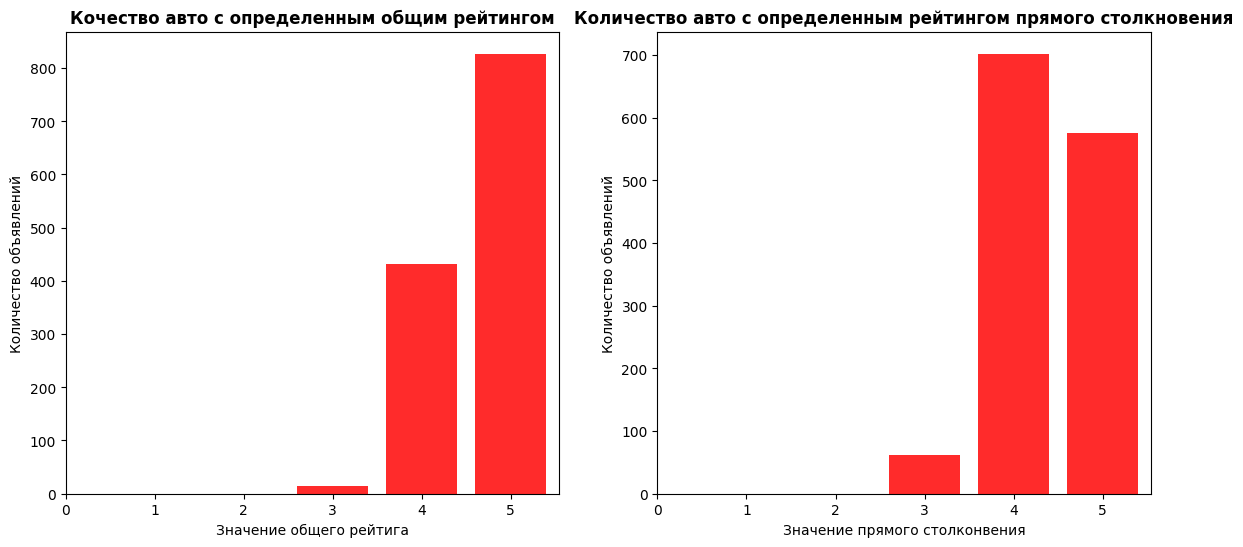

In [2208]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(overall_rating_table.index, overall_rating_table, color = '#FF2B2B')
plt.title('Кочество авто с определенным общим рейтингом', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение общего рейтига')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(front_crash_rating_table.index, front_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом прямого столкновения', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение прямого столконвения')
plt.xticks(range(0, 6))


([<matplotlib.axis.XTick at 0x7de10e0bdb50>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

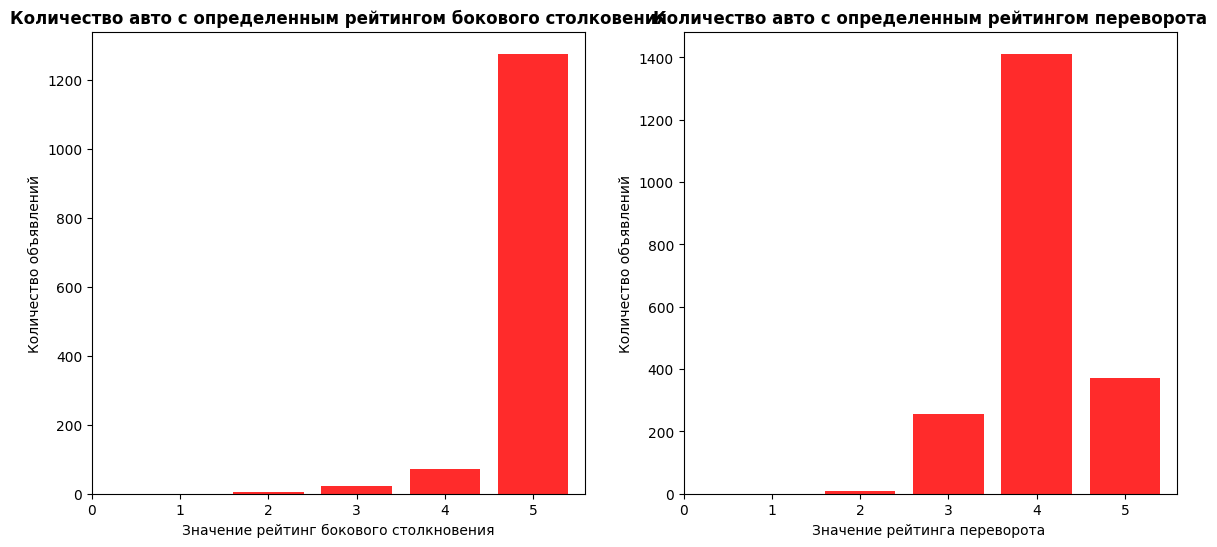

In [2209]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(side_crash_rating_table.index, side_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом бокового столковения', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение рейтинг бокового столкновения')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(rollover_rating_table.index, rollover_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом переворота', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение рейтинга переворота ')
plt.xticks(range(0, 6))

КАКОЙ-ТО ВЫВОД ПО 4 РЕЙТИНГОВЫМ ПАРАМЕТРАМ

14.manufacturer_country - страна выпуска модели автомобиля

Давайте посмотрим какое у нас распределение автомобилей по странам производства

In [2210]:
country_table = pd.pivot_table(df, values = 'url', index = 'manufacturer_country', aggfunc = 'count')
country_table

,url
manufacturer_country,
CHINA,301
GERMANY,1116
ITALY,10
JAPAN,213
MEXICO,176
SLOVAKIA,202
UNITED STATES (USA),2304


Text(0, 0.5, 'Количество автомобилей(объявлений)')

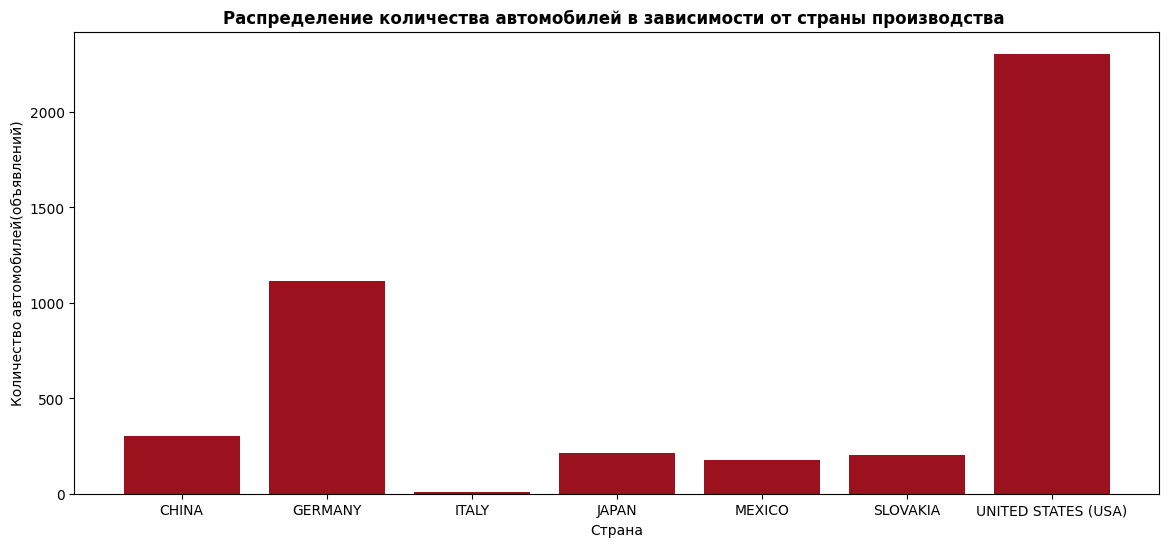

In [2211]:
plt.figure(figsize = (14, 6))
plt.bar(country_table.index, country_table['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от страны производства ', fontweight = 'bold')
plt.xlabel('Страна')
plt.ylabel('Количество автомобилей(объявлений)')

КАКОЙ-ТО ВЫВОД АМЕРИКА ТОП ПОТОМ ГЕРМАНИЯ

15.model_exists - маркер о существовании такой модели автомобиля. В нашем датасете если модели нет, то и информации по ней нет. Это исключительно технических столбец для апи, поэтому мы его удаляем

In [2212]:
df['model_exists'].unique()

array([False,  True])

16.title - заголовок объявления о продаже конкретного авто
это все заголовки, которые прописывает автор объявления при их создании, сожержит общую текстовую информацию об объявлении

In [2213]:
df['title'].sample(5)

,title
6608,"Продажа Infiniti FX37, 2012 год в Ижевске"
7588,"Продажа Zeekr 9X, 2025 год в Москве"
5036,Audi A7 2016 в Екатеринбурге
1655,"Продажа Nissan X-Trail, 2015 год в Санкт-Петер..."
6288,"Продажа Lexus LX570, 2007 год в Бийске"


17.city - город, в котором осуществляется продажа конкретного авто

In [2214]:
city_pivot = pd.pivot_table(df, values = 'url', index = 'city', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

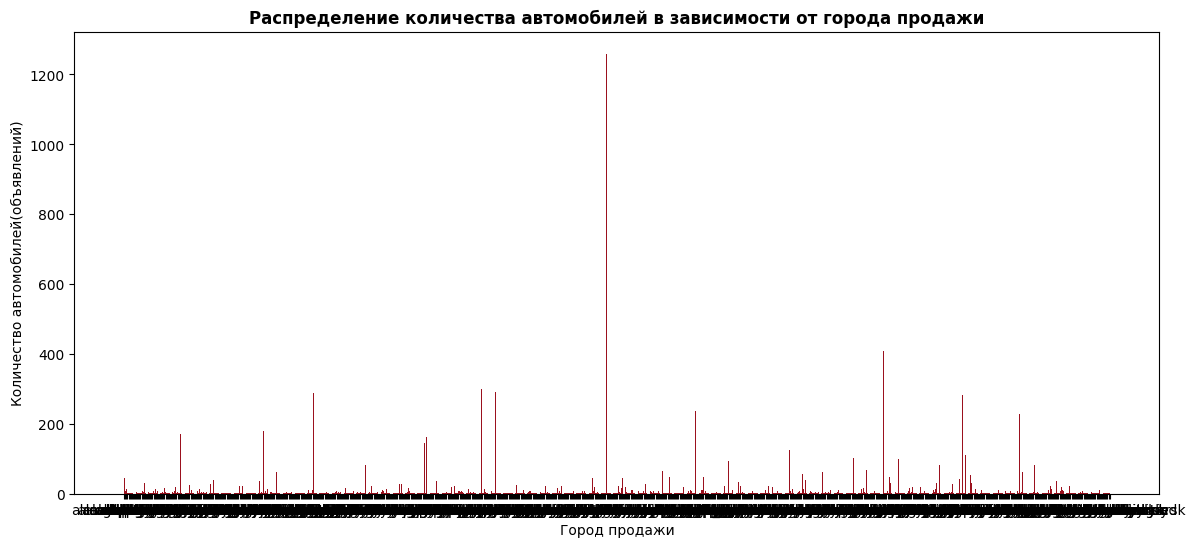

In [2215]:
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')

Ой, что-то огромное, давайте для наглядности возьмем 20 городов, с наибольшим количеством объявлений

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'nizhniy-novgorod'),
  Text(1, 0, 'perm'),
  Text(2, 0, 'surgut'),
  Text(3, 0, 'simferopol'),
  Text(4, 0, 'ufa'),
  Text(5, 0, 'rostov-na-donu'),
  Text(6, 0, 'kazan'),
  Text(7, 0, 'kemerovo'),
  Text(8, 0, 'barnaul'),
  Text(9, 0, 'chelyabinsk'),
  Text(10, 0, 'vladivostok'),
  Text(11, 0, 'irkutsk'),
  Text(12, 0, 'omsk'),
  Text(13, 0, 'tyumen'),
  Text(14, 0, 'ekaterinburg'),
  Text(15, 0, 'krasnoyarsk'),
  Text(16, 0, 'krasnodar'),
  Text(17, 0, 'spb'),
  Text(18, 0, 'novosibirsk'),
  Text(19, 0, 'moscow')])

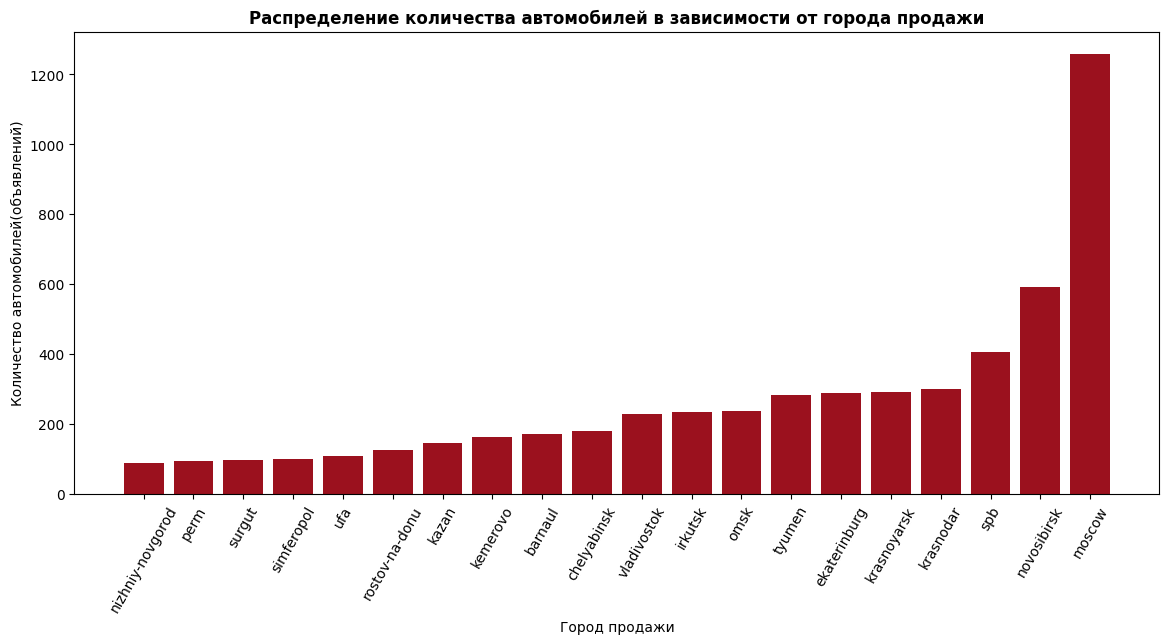

In [2216]:
city_pivot = city_pivot.sort_values(by = 'url').tail(20)
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')

plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 60)

КАКОЙ_ТО ТЕКСТ

18.price - цена конкретного автомобиля

In [2217]:
price_table = pd.cut(df['price'], bins = [0, 500000, 1000000, 2000000, 4000000, 6000000, 10000000, 4000000000],
    labels = ['до 500.000', '500.000 – 1.000.000', '1.000.000 – 2.000.000', '2.000.000 – 4.000.000', '4.000.000 – 6.000.000',
              '6.000.000 – 10.000.000', '10.000.000+'])
price_table = price_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'до 500.000'),
  Text(1, 0, '500.000 – 1.000.000'),
  Text(2, 0, '1.000.000 – 2.000.000'),
  Text(3, 0, '2.000.000 – 4.000.000'),
  Text(4, 0, '4.000.000 – 6.000.000'),
  Text(5, 0, '6.000.000 – 10.000.000'),
  Text(6, 0, '10.000.000+')])

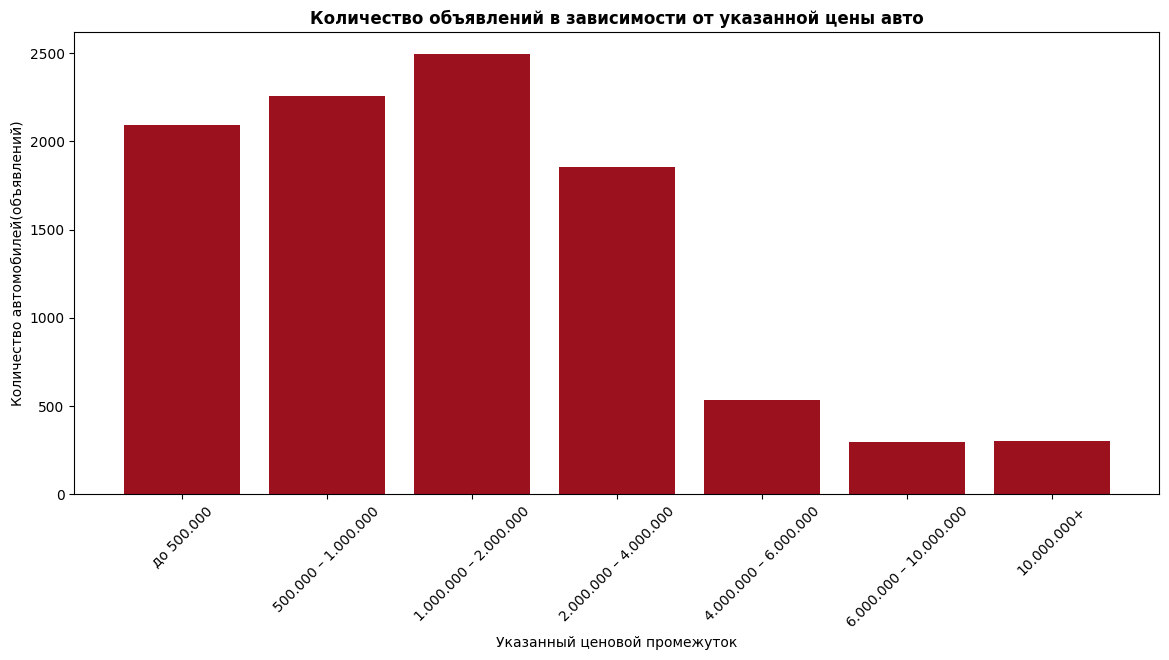

In [2218]:
plt.figure(figsize = (14, 6))
plt.bar(price_table.index, price_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной цены авто', fontweight = 'bold')
plt.xlabel('Указанный ценовой промежуток')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ВЫВОД: НУ МЫ БЕДНЫЕ И МАШИН ПОДЕШЕВЛЕ СИЛЬНО БОЛЬШЕ


19.engine - тип топлива, объем двигателя и дополнительное оборудование

In [2219]:
df['engine'].unique()

array(['бензин, 2.0 л', 'бензин, 1.5 л', 'бензин, 1.6 л', 'бензин, 3.8 л',
       'бензин, 2.5 л', 'бензин, 1.8 л, гибрид', 'дизель, 2.2 л',
       'бензин, 3.0 л', 'бензин, 1.4 л', 'дизель, 4.0 л', 'бензин, 2.4 л',
       'бензин, 3.5 л', 'бензин, 1.8 л', 'дизель, 2.5 л', 'бензин, 2.7 л',
       'дизель, 2.8 л', 'бензин, 2.5 л, ГБО', 'дизель, 4.5 л',
       'дизель, 3.0 л', 'дизель, 2.0 л', 'дизель, 1.6 л', 'бензин, 1.3 л',
       'бензин, 1.5 л, ГБО', 'бензин, 1.3 л, ГБО', 'бензин, 1.0 л',
       'бензин, 2.0 л, ГБО', 'бензин, 1.6 л, ГБО', 'бензин, 4.6 л',
       'бензин, 2.4 л, гибрид, ГБО', '1.8 л', 'бензин, 5.0 л',
       'бензин, 2.5 л, гибрид', 'бензин, 1.8 л, ГБО',
       'бензин, 2.4 л, гибрид', 'бензин, 1.6 л, гибрид', 'бензин, 1.2 л',
       'дизель, 4.2 л', 'бензин, 1.4 л, ГБО', 'бензин, 3.4 л',
       'дизель, 1.7 л', '2.0 л', nan, 'бензин, 3.5 л, гибрид',
       'бензин, 4.0 л', 'бензин, 2.4 л, ГБО', 'бензин, 1.1 л',
       'бензин, 4.7 л', 'бензин, 2.0 л, гибрид', 'бензи

Тип топлива принимает значения: бензин, дизель, электро
Также есть дополнительное оборудование машины в виде ГБО

ДОПИСАТЬ ПОТОМ КАК ДОДЕЛАЕМ

20.transmission - тип коробки передач у конкретного автомобиля


In [2220]:
transmission_table = pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

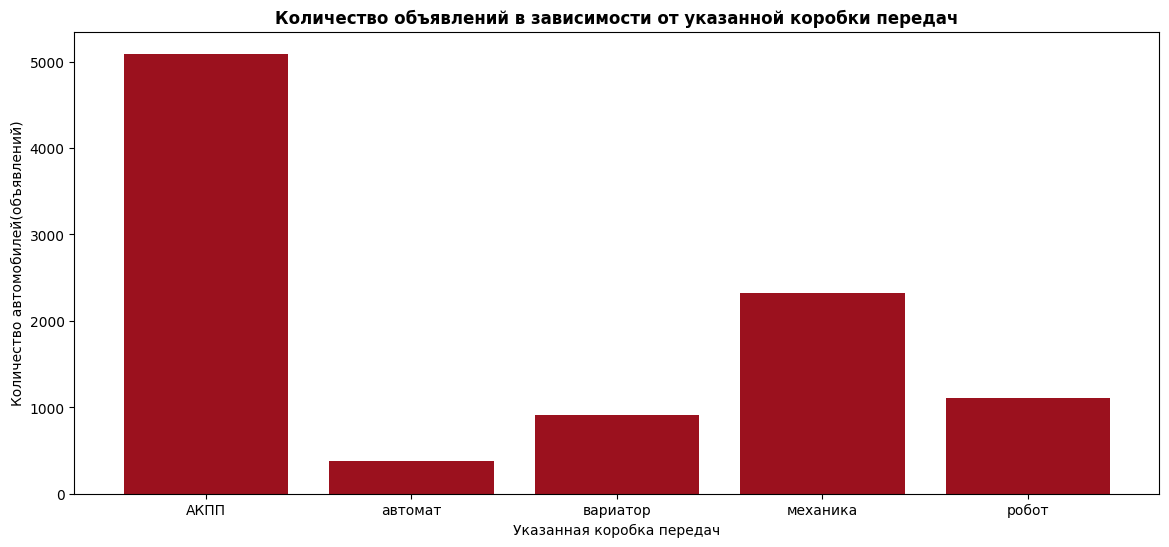

In [2221]:
plt.figure(figsize = (14, 6))
plt.bar(transmission_table.index, transmission_table['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной коробки передач', fontweight = 'bold')
plt.xlabel('Указанная коробка передач')
plt.ylabel('Количество автомобилей(объявлений)')

АКПП и автомат - это одно и то же, поэтому заменим все значения "автомат" на "АКПП"
НУ И КОНЕЧНО КАКОЙ-ТО ТЕКСТИК

In [2222]:
df.loc[df['transmission'] == 'автомат', 'transmission'] = 'АКПП'

In [2223]:
pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

,url
transmission,
АКПП,5474
вариатор,913
механика,2326
робот,1103


теперь все супер!

21.mileage - пробег конкретного автомобилят, измеряется в километрах

Посмотрим на распределение пробега,

In [2224]:
df['mileage'].min()

1.0

In [2225]:
df['mileage'].max()

999999.0

In [2226]:
mileage_table = pd.cut(df['mileage'], bins = [0, 10000, 30000, 50000, 100000, 150000, 200000, 300000, 400000, 600000, 1000000],
    labels = ['до 10.000', '10.000 - 30.000', '30.000 - 50.000', '50.000 – 100.000', '100.000 – 150.000', '150.000 – 200.000', '200.000 – 300.000',
              '300.000 – 400.000', '400.000 - 600.000', '600000+'])
mileage_table = mileage_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'до 10.000'),
  Text(1, 0, '10.000 - 30.000'),
  Text(2, 0, '30.000 - 50.000'),
  Text(3, 0, '50.000 – 100.000'),
  Text(4, 0, '100.000 – 150.000'),
  Text(5, 0, '150.000 – 200.000'),
  Text(6, 0, '200.000 – 300.000'),
  Text(7, 0, '300.000 – 400.000'),
  Text(8, 0, '400.000 - 600.000'),
  Text(9, 0, '600000+')])

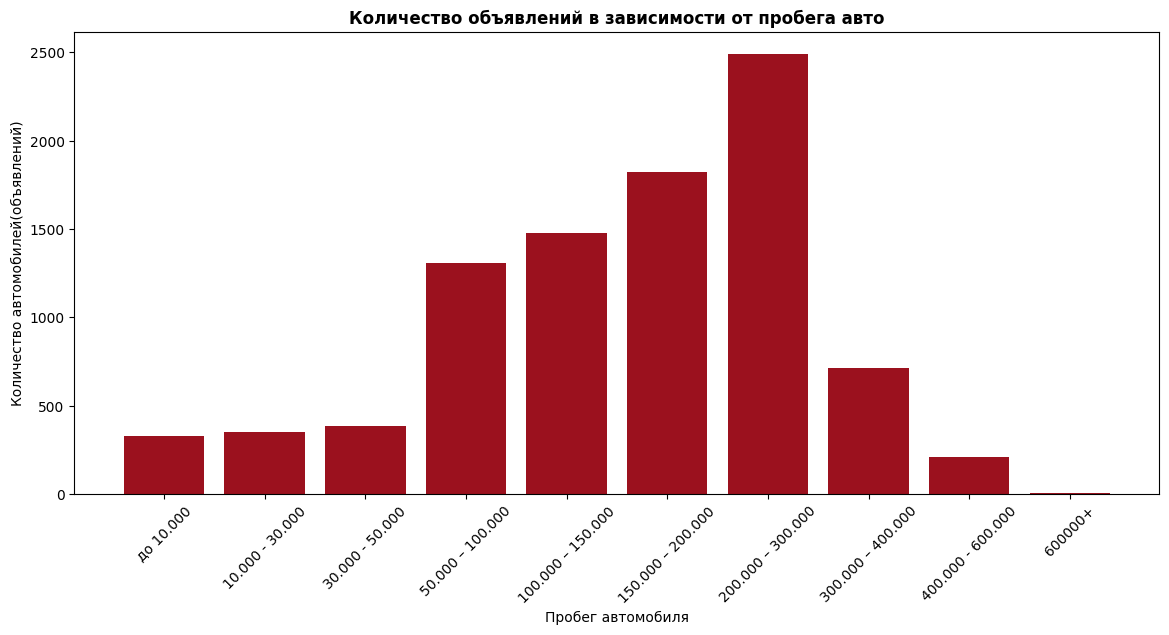

In [2227]:
plt.figure(figsize = (14, 6))
plt.bar(mileage_table.index, mileage_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от пробега авто', fontweight = 'bold')
plt.xlabel('Пробег автомобиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ВЫВОД

22.drive - тип привода конкретного автомобиля

In [2228]:
drive_pivot = pd.pivot_table(df, values = 'url', index = 'drive', aggfunc = 'count')

([0, 1, 2], [Text(0, 0, '4WD'), Text(1, 0, 'задний'), Text(2, 0, 'передний')])

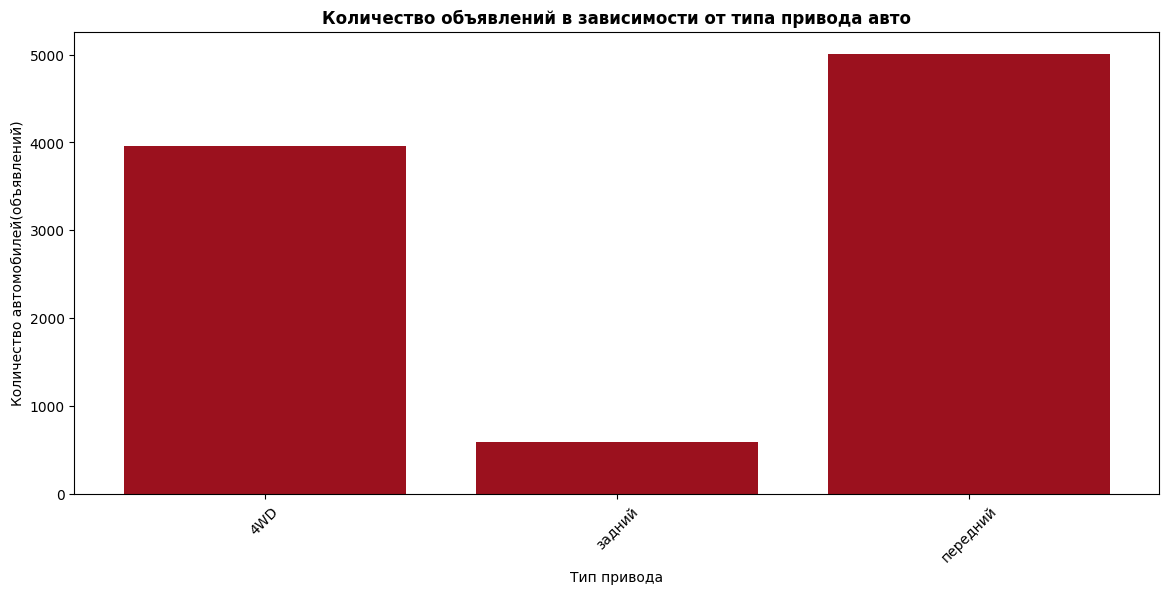

In [2229]:
plt.figure(figsize = (14, 6))
plt.bar(drive_pivot.index, drive_pivot['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа привода авто', fontweight = 'bold')
plt.xlabel('Тип привода')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ТЕКСТИК

23.body - тип кузова конкретного автомобиля

In [2230]:
body_table = df['body'].value_counts()
body_table

,count
body,
седан,1983
хэтчбек 5 дв.,885
джип/suv 5 дв.,544
лифтбек,348
универсал,323
хэтчбек 3 дв.,178
купе,89
джип/suv 3 дв.,65
пикап,23


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'седан'),
  Text(1, 0, 'хэтчбек 5 дв.'),
  Text(2, 0, 'джип/suv 5 дв.'),
  Text(3, 0, 'лифтбек'),
  Text(4, 0, 'универсал'),
  Text(5, 0, 'хэтчбек 3 дв.'),
  Text(6, 0, 'купе'),
  Text(7, 0, 'джип/suv 3 дв.'),
  Text(8, 0, 'пикап'),
  Text(9, 0, 'минивэн'),
  Text(10, 0, 'открытый')])

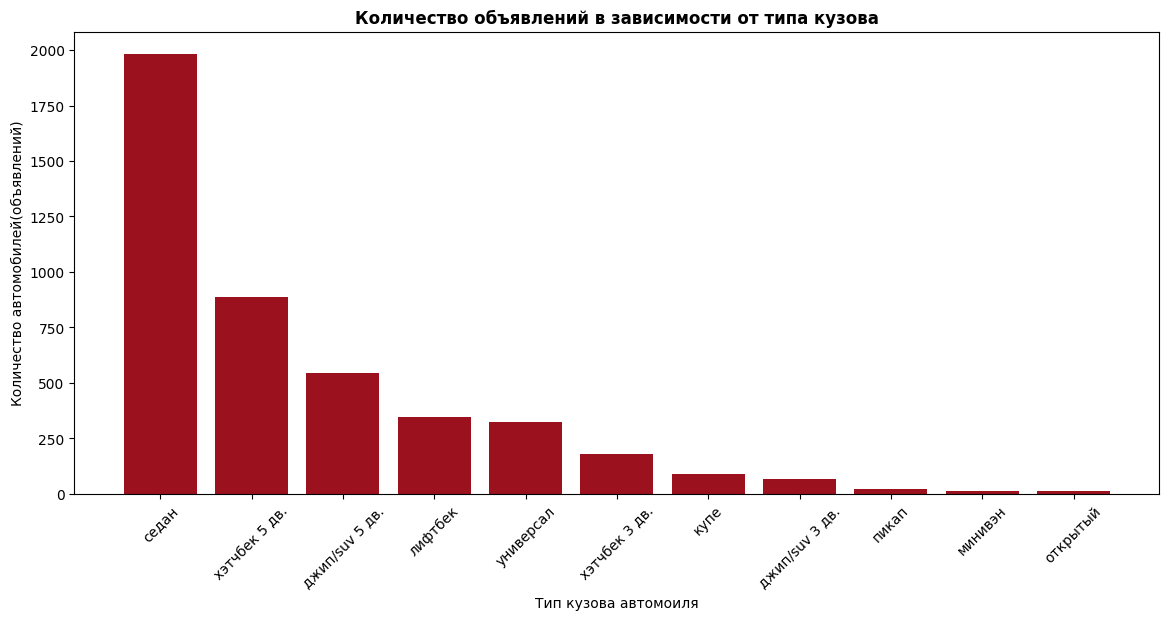

In [2231]:
plt.figure(figsize = (14, 6))
plt.bar(body_table.index, body_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа кузова', fontweight = 'bold')
plt.xlabel('Тип кузова автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

ТЕКСТИК

24.color - цвет конкретного автомобиля

In [2232]:
color_table = df['color'].value_counts()
color_table

,count
color,
черный,2328
белый,2078
серый,1586
синий,872
серебристый,803
красный,498
зеленый,299
коричневый,281
голубой,136


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'черный'),
  Text(1, 0, 'белый'),
  Text(2, 0, 'серый'),
  Text(3, 0, 'синий'),
  Text(4, 0, 'серебристый'),
  Text(5, 0, 'красный'),
  Text(6, 0, 'зеленый'),
  Text(7, 0, 'коричневый'),
  Text(8, 0, 'голубой'),
  Text(9, 0, 'бежевый'),
  Text(10, 0, 'бордовый'),
  Text(11, 0, 'оранжевый'),
  Text(12, 0, 'золотистый'),
  Text(13, 0, 'фиолетовый'),
  Text(14, 0, 'желтый'),
  Text(15, 0, 'розовый')])

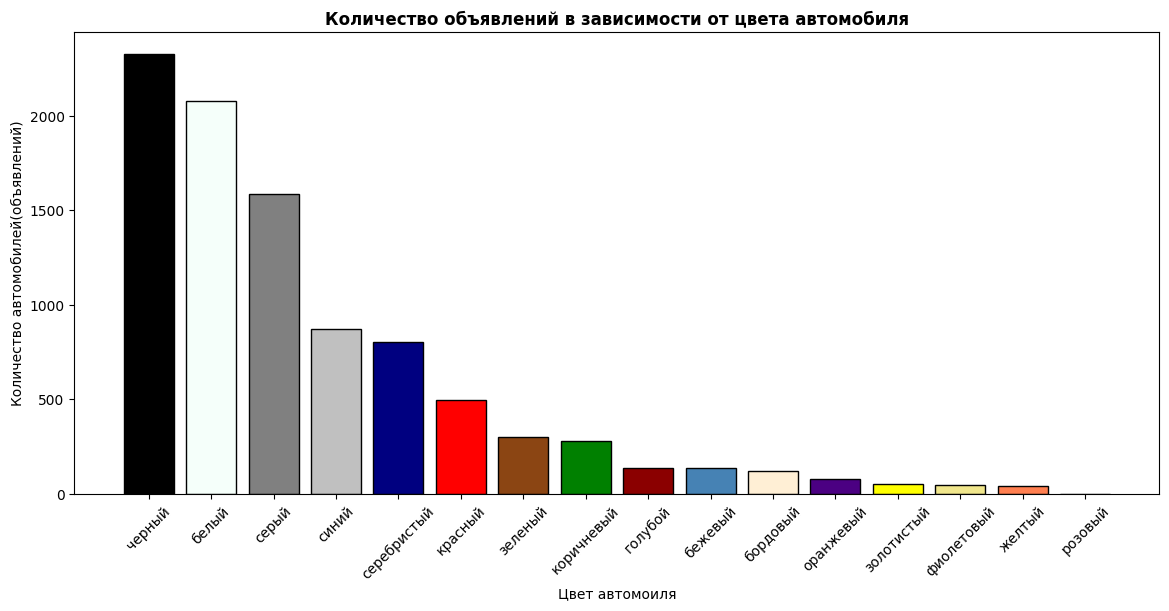

In [2233]:
plt.figure(figsize = (14, 6))
plt.bar(color_table.index, color_table, color = ['#000000', '#F5FFFA', '#808080', '#C0C0C0', '#000080', '#FF0000', '#8B4513',
                                                 '#008000', '#8B0000', '#4682B4', '#FFEFD5', '#4B0082', '#FFFF00',
                                                 '#F0E68C', '#FF7F50', '#FF69B4'], edgecolor = 'black', linewidth = 1)

plt.title('Количество объявлений в зависимости от цвета автомобиля', fontweight = 'bold')
plt.xlabel('Цвет автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ-ТО ТЕКСТИК

25.wheel - расположение руля в конкретном автомобиле

In [2234]:
wheel_table = df['wheel'].value_counts()
wheel_table

,count
wheel,
левый,8322
правый,1157


Text(0.5, 1.0, 'Количество автомобилей в зависимости от расположения руля')

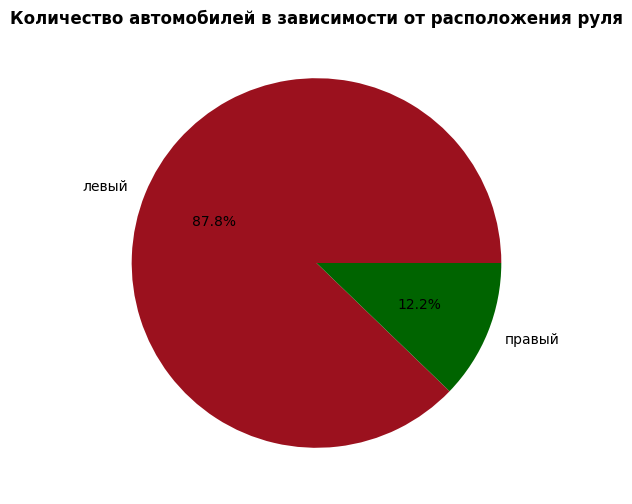

In [2235]:
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от расположения руля', fontweight = 'bold')

КАКОЙ-ТО ТЕКСТ

26.hp - количество лошадиных сил конкретного автомобиля

In [2236]:
gp_table = pd.cut(df['hp'], bins = [0, 80, 110, 156, 200, 252, 300, 500, 2000],
    labels = ['до 80', '80 - 110', '110 - 156', '156 - 200', '200 – 252', '252 - 300', '300 - 500',
              '500+'])
gp_table = gp_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'до 80'),
  Text(1, 0, '80 - 110'),
  Text(2, 0, '110 - 156'),
  Text(3, 0, '156 - 200'),
  Text(4, 0, '200 – 252'),
  Text(5, 0, '252 - 300'),
  Text(6, 0, '300 - 500'),
  Text(7, 0, '500+')])

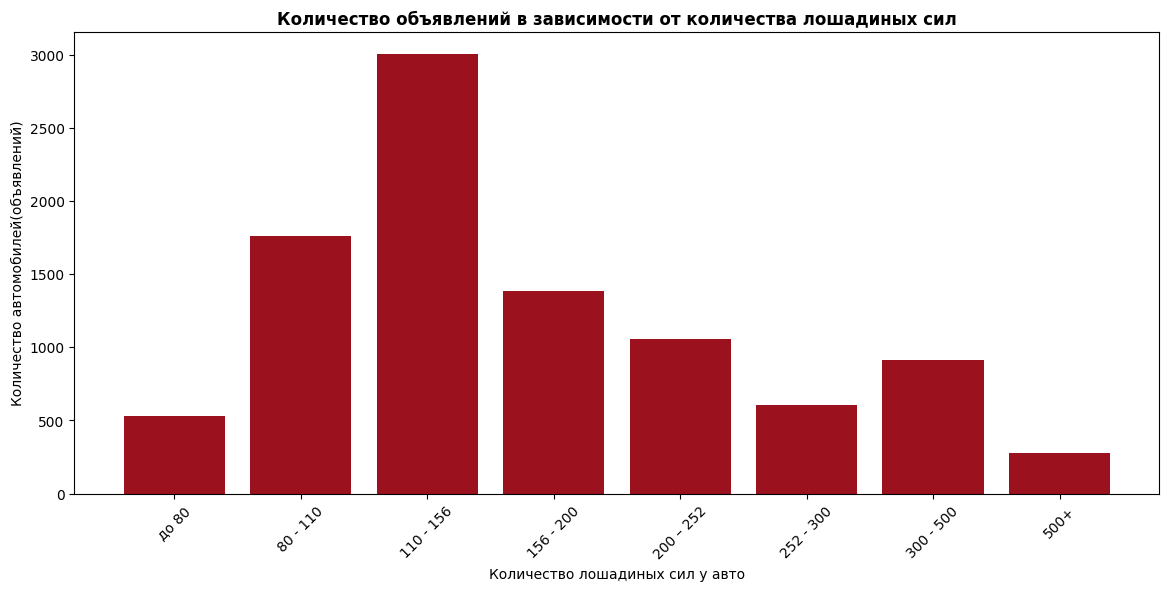

In [2237]:
plt.figure(figsize = (14, 6))
plt.bar(gp_table.index, gp_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от количества лошадиных сил', fontweight = 'bold')
plt.xlabel('Количество лошадиных сил у авто')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

КАКОЙ_ТО ТЕКСТ

# Feature Engineering и корректировка значений

Сначала поработаем со столбцом engine. Вычленим из него два признака - это тип топлива и объем двигателя. Дополнительное оборудование в виде ГБО не будем включать в наш анализ


После поработаем с признаком пробега. Пока там существуют проспуски. Но в случае с машинами 2025 и 2026 года выпуска пропуски это не отсутсвие значения (NaN), а скорее отсутсвие пробега у авто. Так что у таких авто мы заменим нан на 0

In [2238]:
df['engine'].sample(3)

,engine
4746,"бензин, 1.6 л"
9883,"бензин, 1.6 л"
8929,"бензин, 3.0 л"


In [2239]:
split_engine = df['engine'].str.split(',', expand = True)
split_engine.sample(4)

,0,1,2,3
5013,бензин,3.0 л,None,None
7909,бензин,6.2 л,None,None
6698,бензин,2.5 л,None,None
2048,бензин,4.8 л,None,None


In [2240]:
df['oil_type'] = split_engine[0]
df['oil_type'].sample(5)

,oil_type
8977,дизель
8451,бензин
1624,бензин
5277,бензин
1898,бензин


In [2241]:
df['engine_volume'] = split_engine[1]
df['engine_volume'].sample(5)

,engine_volume
8861,2.4 л
6504,5.7 л
5246,1.4 л
2969,1.6 л
9252,0.7 л


In [2242]:
df.head(2)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,transmission,mileage,drive,body,color,wheel,hp,description,oil_type,engine_volume
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,toyota,crown,1990,0,0,0,0,0,0,...,АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...,бензин,2.0 л
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,224,15,2,6,20,...,АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...,бензин,2.0 л


In [2243]:
df = df.drop('engine', axis = 1)

In [2244]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,8389
дизель,897
электро,494
2.0 л,6
110 000 ₽,5
1.8 л,4
1.6 л,3
3.4 л,2
120 000 ₽,2


Удалим ненужные строки, так как у них все равно пропуски в типе топлива

In [2245]:
df.shape

(9832, 34)

In [2246]:
df = df[df['oil_type'].isin(['бензин', 'дизель', 'электро'])]

In [2247]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,8389
дизель,897
электро,494


Text(0, 0.5, 'Количество автомобилей(объявлений)')

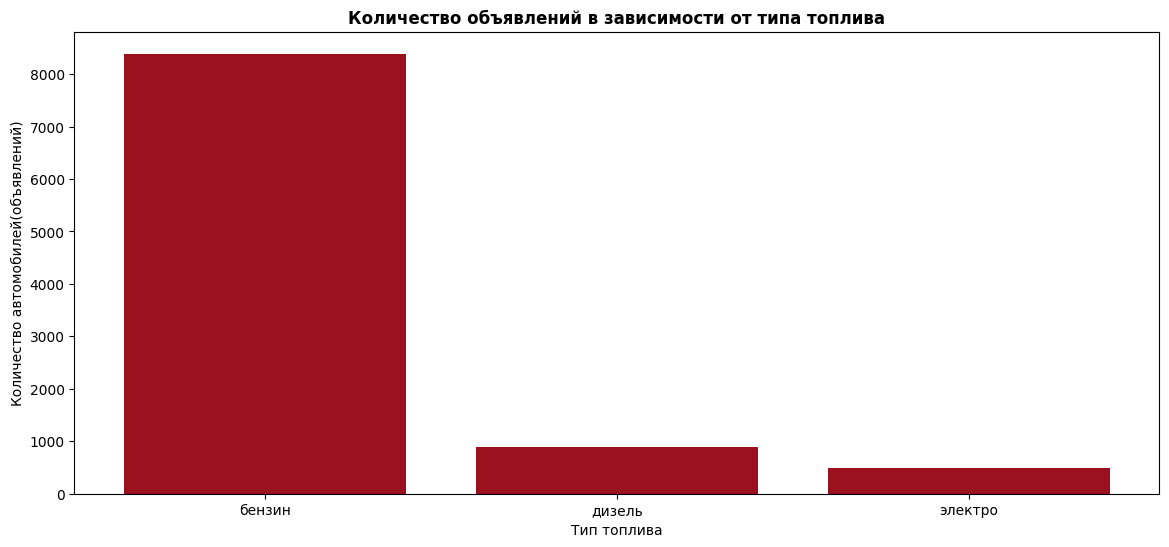

In [2248]:
plt.figure(figsize = (14, 6))
plt.bar(oil_table.index, oil_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа топлива', fontweight = 'bold')
plt.xlabel('Тип топлива')
plt.ylabel('Количество автомобилей(объявлений)')

In [2249]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
0.5 л,1
0.7 л,57
0.8 л,4
0.9 л,4
1.0 л,32
1.1 л,10
1.2 л,215
1.3 л,155
1.4 л,678


In [2250]:
df = df.drop(df[df['engine_volume'] == ' ГБО'].index)

In [2251]:
df['engine_volume'] = df['engine_volume'].str.strip().str[:3].astype(float)

In [2252]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
0.5,1
0.7,57
0.8,4
0.9,4
1.0,32
1.1,10
1.2,215
1.3,155
1.4,678


Text(0, 0.5, 'Количество автомобилей(объявлений)')

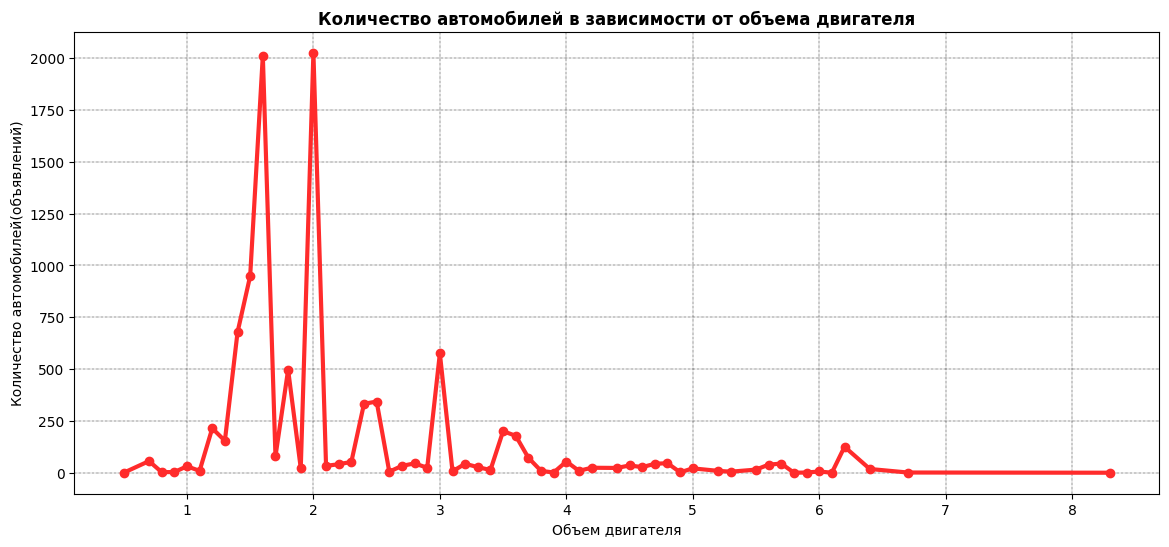

In [2253]:
plt.figure(figsize = (14, 6))

plt.plot(volume_table.index, volume_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)
plt.title('Количество автомобилей в зависимости от объема двигателя', fontweight = 'bold')
plt.xlabel('Объем двигателя')
plt.ylabel('Количество автомобилей(объявлений)')

КАКОЙ-ТО ТЕКСТИК

Теперь у машин 2025 и 2026 года поменяем нан в пробеге на ноль

In [2254]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (388, 34)
Авто 2026 года выпуска без пробега (157, 34)


In [2255]:
df.loc[(df['mileage'].isnull()) & (df['year'] == 2025), 'mileage'] = 0.0
df.loc[(df['mileage'].isnull()) & (df['year'] == 2026), 'mileage'] = 0.0

In [2256]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (0, 34)
Авто 2026 года выпуска без пробега (0, 34)


Теперь все должно быть отлично. Давайте перейдем к трудоемкому, но очень важному этапу

# Обработка пропусков в датасете

сразу давайте удалим ненужный нам признак model_exists

In [2257]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2258]:
df = df.dropna(subset = 'transmission')

In [2259]:
df.shape

(9772, 34)

In [2260]:
df = df.dropna(subset = 'mileage')

In [2261]:
df = df.dropna(subset = 'wheel')

In [2262]:
df = df.dropna(subset = 'drive')

In [2263]:
df = df.dropna(subset = 'hp')

In [2264]:
df = df.dropna(subset = 'color')

In [2265]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


Заполняем медианой по марке и модели пропущенные значение engine_volume

In [2266]:
median_by_mm = (df.groupby(['make'])['engine_volume'].median())

In [2267]:
mask = df['engine_volume'].isnull()
mask

,engine_volume
0,False
1,False
2,False
3,False
5,False
...,...
10008,False
10009,False
10010,False
10011,False


In [2268]:
df.loc[mask, 'engine_volume'] = (df.loc[mask, ['make']].apply(lambda row: median_by_mm[row['make']], axis = 1))

In [2269]:
df['engine_volume'].isnull().sum()

np.int64(230)

In [2270]:
df = df.dropna(subset = 'engine_volume')

In [2271]:
df.shape

(8835, 34)

In [2272]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2273]:
mode_table = df.groupby('make')['body'].value_counts()
mode_table = mode_table.groupby('make').head(1).reset_index()
mode_table

,make,body,count
0,audi,седан,109
1,bmw,седан,101
2,cadillac,джип/suv 5 дв.,124
3,chery,седан,2
4,chevrolet,седан,69
5,citroen,хэтчбек 5 дв.,53
6,dodge,седан,35
7,fiat,хэтчбек 5 дв.,41
8,ford,седан,107
9,geely,седан,15


In [2274]:
df = df.merge(mode_table[['make', 'body']], on = 'make', how = 'left', suffixes = ('', '_moda'))
df.loc[df['body'].isnull(), 'body'] = df.loc[df['body'].isnull(), 'body_moda']
df = df.drop(columns = 'body_moda')
df['body'].isnull().sum()

np.int64(528)

In [2275]:
df = df.dropna(subset = 'body')

In [2276]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2277]:
df['marketcheck_popularity_score'] = df['marketcheck_popularity_score'].replace(0, np.nan)
df['marketcheck_avg_price'] = df['marketcheck_avg_price'].replace(0, np.nan)
df['marketcheck_avg_days_on_market'] = df['marketcheck_avg_days_on_market'].replace(0, np.nan)

In [2278]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2279]:
df = df.drop('matched_model_name', axis = 1)

In [2280]:
df = df.drop('manufacturer_country', axis = 1)

In [2281]:
df = df.drop('model_exists', axis = 1)

In [2282]:
df = df.drop('model_match_status', axis = 1)

In [2283]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2284]:
df_rating = df[['url', 'make', 'model', 'year', 'overall_rating', 'front_crash_rating', 'side_crash_rating', 'rollover_rating', 'price']]

In [2285]:
df_rating.isna().sum()

,0
url,0
make,0
model,0
year,0
overall_rating,7188
front_crash_rating,7132
side_crash_rating,7112
rollover_rating,6463
price,0


In [2286]:
df_rating = df_rating.dropna(subset = 'overall_rating')

In [2287]:
df_rating.isna().sum()

,0
url,0
make,0
model,0
year,0
overall_rating,0
front_crash_rating,0
side_crash_rating,0
rollover_rating,0
price,0


In [2288]:
df_rating.shape

(1119, 9)

In [2289]:
df_rating.to_csv('df_rating.csv')

In [2290]:
df_marketcheck = df[['url', 'make', 'model', 'year', 'marketcheck_avg_days_on_market', 'marketcheck_popularity_score', 'price']]

In [2291]:
df_marketcheck.isna().sum()

,0
url,0
make,0
model,0
year,0
marketcheck_avg_days_on_market,4618
marketcheck_popularity_score,4618
price,0


In [2292]:
df_marketcheck = df_marketcheck.dropna(subset = 'marketcheck_avg_days_on_market')

In [2293]:
df_marketcheck.isna().sum()

,0
url,0
make,0
model,0
year,0
marketcheck_avg_days_on_market,0
marketcheck_popularity_score,0
price,0


In [2294]:
df_marketcheck.shape

(3689, 7)

In [2295]:
df_marketcheck.to_csv('df_marketcheck.csv')

In [2297]:
df_main = df.copy()

In [2298]:
df_main.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2299]:
df_main = df_main.drop(['overall_rating', 'front_crash_rating', 'side_crash_rating', 'rollover_rating',
                        'marketcheck_avg_price', 'marketcheck_avg_days_on_market', 'marketcheck_popularity_score'], axis = 1)

In [2300]:
df_main.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2301]:
df_main.shape

(8307, 23)

In [2302]:
df_main.to_csv('df_main.csv')

In [2303]:
df_main['body'].unique()

array(['седан', 'джип/suv 5 дв.', 'хэтчбек 5 дв.', 'универсал', 'минивэн',
       'лифтбек', 'хэтчбек 3 дв.', 'купе', 'джип/suv 3 дв.', 'открытый',
       'пикап'], dtype=object)